# 1. Import Required Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# ML Libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

import joblib

# 2. Load Dataset

In [45]:
data = pd.read_csv('city_day.csv')
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


# 3. Data Preprocessing

In [46]:
# Remove missing values
clean_data = data.dropna()

# Select features (modify if needed)
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3']

x = clean_data[features]
y = clean_data['AQI']

# 4. Train-Test Split

In [47]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# 5. Model Training & Comparison

In [48]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('SVR', SVR()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('AdaBoost', AdaBoostRegressor()),
    ('Lasso', Lasso()),
    ('Ridge', Ridge()),
    ('ElasticNet', ElasticNet())
]

results = {'Model': [], 'MAE': [], 'MSE': [], 'R2 Score': []}

for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    results['Model'].append(name)
    results['MAE'].append(mean_absolute_error(y_test, y_pred))
    results['MSE'].append(mean_squared_error(y_test, y_pred))
    results['R2 Score'].append(r2_score(y_test, y_pred))

# 6. Model Performance Visualization

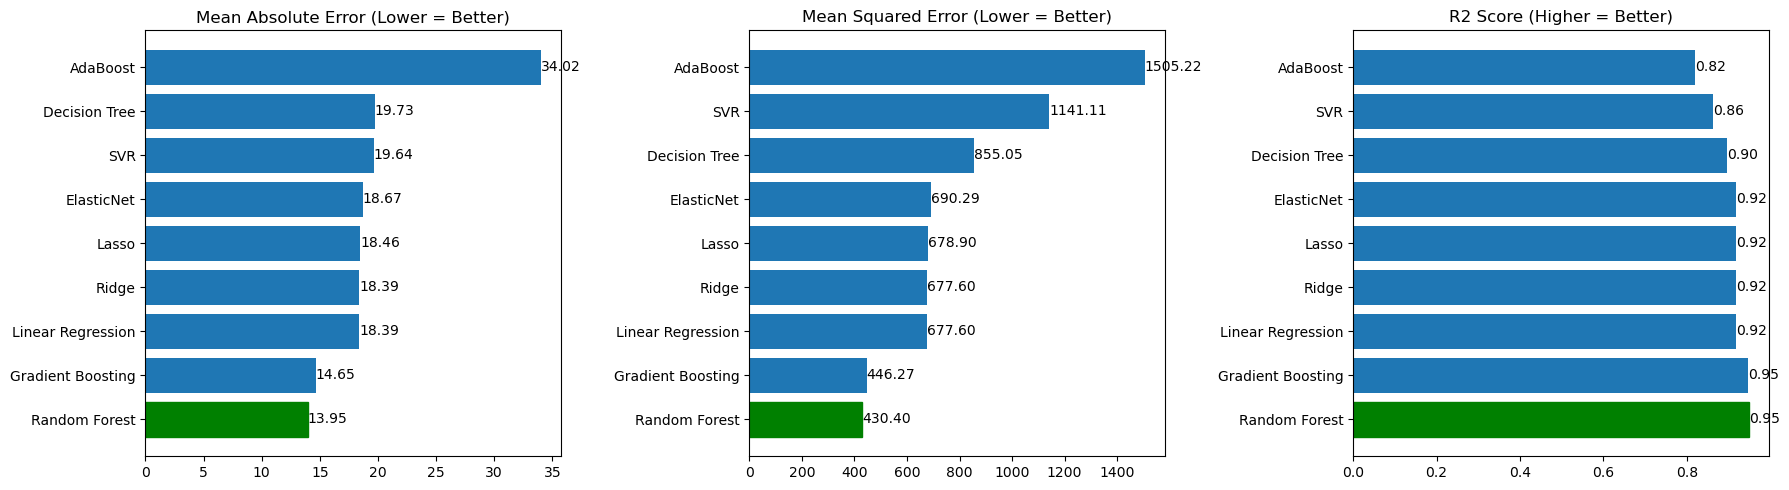

In [49]:
results_df = pd.DataFrame(results)

# Sort by R2 Score (best on top)
results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Function to add labels
def add_labels(axis):
    for i, v in enumerate(axis.patches):
        axis.text(v.get_width(), v.get_y() + v.get_height()/2, 
                  f"{v.get_width():.2f}", va='center')

# MAE (lower is better)
mae_sorted = results_df.sort_values(by='MAE')
bars = ax[0].barh(mae_sorted['Model'], mae_sorted['MAE'])

# Highlight best (lowest MAE)
bars[0].set_color('green')

ax[0].set_title('Mean Absolute Error (Lower = Better)')
add_labels(ax[0])

# MSE (lower is better)
mse_sorted = results_df.sort_values(by='MSE')
bars = ax[1].barh(mse_sorted['Model'], mse_sorted['MSE'])

bars[0].set_color('green')

ax[1].set_title('Mean Squared Error (Lower = Better)')
add_labels(ax[1])

# R2 Score (higher is better)
bars = ax[2].barh(results_df['Model'], results_df['R2 Score'])

# Highlight best (highest R2)
bars[0].set_color('green')

ax[2].set_title('R2 Score (Higher = Better)')
add_labels(ax[2])

plt.tight_layout()
plt.show()

# 7. Best Model Selection

In [50]:
print(results_df.sort_values(by='R2 Score', ascending=False).head(2))

               Model        MAE         MSE  R2 Score
0      Random Forest  13.949367  430.397766  0.948271
1  Gradient Boosting  14.649223  446.267001  0.946363


In [51]:
model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# 8. Actual vs Predicted Visualization

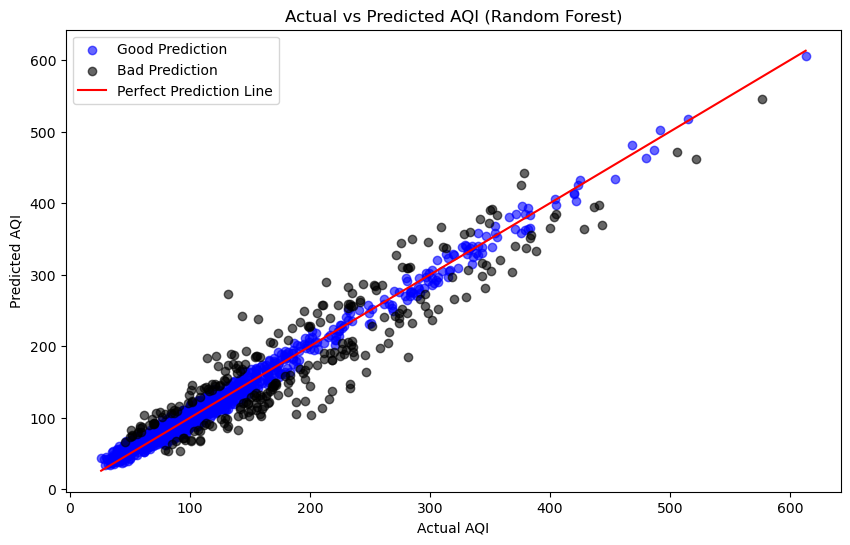

In [52]:
plt.figure(figsize=(10, 6))

errors = abs(y_test - y_pred) # Calculate error

threshold = 20 # Define threshold 

# Split points
good = errors <= threshold
bad = errors > threshold

plt.scatter(y_test[good], y_pred[good], color='blue', label="Good Prediction", alpha=0.6)
plt.scatter(y_test[bad], y_pred[bad], color='black', label="Bad Prediction", alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
        label='Perfect Prediction Line')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Random Forest)")

plt.legend()
plt.show()

# 9. Hyperparameter Tuning 

In [53]:
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(x_train, y_train)

best_params = random_search.best_params_
best_score = random_search.best_score_

print(best_params)
print(best_score)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
0.9396331276680406


# 10. Final Model Training

In [54]:
final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(x_train, y_train)

y_pred_final = final_model.predict(x_test)

print("Final R2 Score:", r2_score(y_test, y_pred_final))

Final R2 Score: 0.9475281094348743


# 11. Real-Time Data Prediction (API)

In [58]:
url = "http://api.openweathermap.org/data/2.5/air_pollution?lat=23.03&lon=72.58&appid=74bd8aa4ee544b2d53c36cf5ef9a93ea"

response = requests.get(url)

if response.status_code == 200:
    result = response.json()
    
    comp = result['list'][0]['components']
    
    # Extract features for prediction
    rt_data = {
        'PM2.5': comp['pm2_5'],
        'PM10': comp['pm10'],
        'NO': comp['no'],
        'NO2': comp['no2'],
        'NH3': comp['nh3'],
        'CO': comp['co'],
        'SO2': comp['so2'],
        'O3': comp['o3']
    }

    rt_df = pd.DataFrame([rt_data])

    # Predict AQI
    prediction = final_model.predict(rt_df)[0]

    # Get API AQI (1–5 scale)
    api_aqi = result['list'][0]['main']['aqi']

    # API category mapping
    aqi_map = {
        1: "Good",
        2: "Fair",
        3: "Moderate",
        4: "Poor",
        5: "Very Poor"
    }

    # Convert predicted AQI to category (aligned with API naming)
    def categorize_aqi(aqi):
        if aqi <= 50:
            return "Good"
        elif aqi <= 100:
            return "Fair"   # changed from Satisfactory
        elif aqi <= 200:
            return "Moderate"
        elif aqi <= 300:
            return "Poor"
        elif aqi <= 400:
            return "Very Poor"
        else:
            return "Severe"

    predicted_category = categorize_aqi(prediction)
    api_category = aqi_map[api_aqi]

    print("Predicted AQI:", round(prediction, 2))
    print("Predicted Category:", predicted_category)
    print("API Category:", api_category)

else:
    print("API Error:", response.status_code)

Predicted AQI: 103.74
Predicted Category: Moderate
API Category: Fair


# 12. Save Model

In [59]:
joblib.dump(final_model, 'aqi_model.joblib')

['aqi_model.joblib']